# Logistic Regression - Breast Cancer Dataset

## Objective

This notebook explores logistic regression using the Breast Cancer Wisconsin (Diagnostic) dataset.

### Research Question

Can we use tumour characteristics to predict malignancy of breast tumour?

### Learning Objectives
- Understand the purpose of logistic regression for binary classification
- Explore the relationship between tumour characteristics and diagnosis
- Fit and interpret a logistic regression model
- Understand probability, odds, and odds ratios in logistic regression
-Evaluate the model's classification performance


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Set up Complete")

Set up Complete


## 01. Dataset & Initial Exploration
### 1.1 Load and Inspect Data

In [7]:
df = pd.read_csv('wdbc.csv')
df.head()
df.info()
df.describe()
print(df.shape)
print(df.columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

### 1.2 Remove Unnecessary Columns

The 'id' column is an identifier for each sample and does not provide useful information for predicting diagnoses.

'Unnamed: 32' is an empty column and contains no useful information.

Both columns will therefore be removed. 

In [19]:
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 1.3 Explore & Visualise the Target Variable

The target variable is 'diagnosis', which indicates whether a tumour is 
'M' Malignant, or 'B' Benign.

Beofre building the logistic regression model, we first examine the distribution of the two classes, and use a bar chart to help us quickly visualise the number of benign and malignant cases in the dataset.


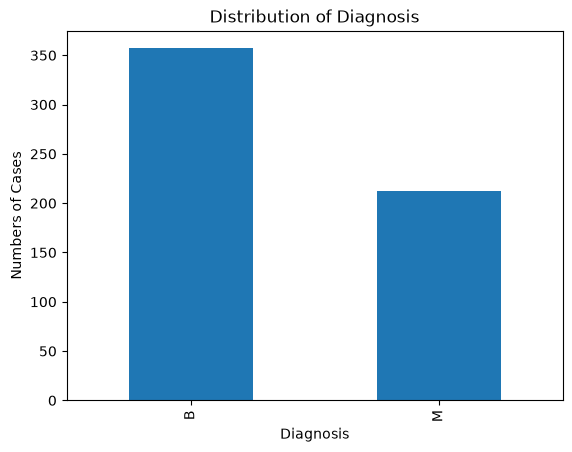

In [25]:
#Value count of diagnosis column
df['diagnosis'].value_counts()

#Proportion of diagnosis column
df['diagnosis'].value_counts(normalize=True)

#Visualise distribution of diagnosis using a bar chart
df['diagnosis'].value_counts().plot(kind='bar')
plt.title('Distribution of Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Numbers of Cases')
plt.show()

### 1.4 Explore the Predictor Variables

The dataset contains 30 numerical predictor variables derived from images of cell nuclei, divided into 10 core cell features:
1. Radius (Mean of distances from center to points on the perimeter)
2. Perimeter
3. Area
4. Compactness (Perimeter^2 / area-1.0)
5. Concavity (Severity of concave portions of the contour)
6. Concave points ( Number of concave portions of the contour)
7. Texture (Standard devation of gray-scale values)
8. Smoothness (Local variation in radius lengths)
9. Symmetry
10. Fractal dimension ("Coastline approximation" -1)
Each feature is represented by three statistical metrics: the mean, the standard error, and the worst value.
These features describe characteristics of cell nuclei rather than measurements of breast tumour.


In [29]:
predictors = df.columns.drop('diagnosis')
print(predictors)
df[predictors].describe().T

Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='str')


,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


### 1.5 Explore specific predictor variable: radius_mean

'radius_mean' represents the mean distances from centre of nell nucleus to points on its perimeter. We first examine whether 'radius_mean' differs between benign and malignant samples.

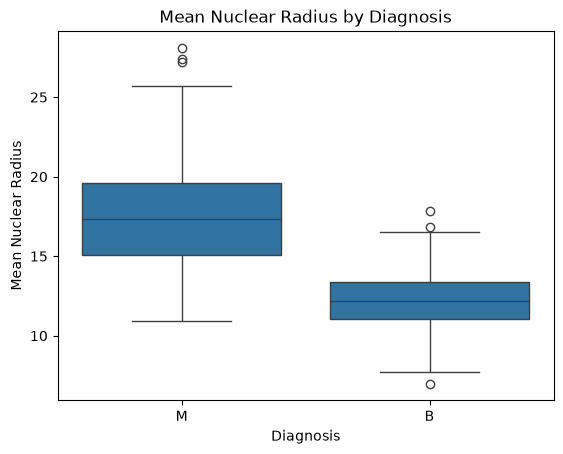

In [32]:
#statistics of radius_mean for each diagnosis group
df.groupby('diagnosis')['radius_mean'].describe()

#visualise data
sns.boxplot(data=df, x='diagnosis', y='radius_mean')
plt.title('Mean Nuclear Radius by Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Mean Nuclear Radius')
plt.show()

#### Observation
The distribution of 'radius_mean' appears to be higher for malignant samples than it is for benign samples. This suggests that mean nuclear radius may contain useful information in predicting probability that a sample is malignant.

### 1.6 Prepare Target Variable
Currently, diagnoses are categorised into B = Benign, and M = Malignant. Logistic regression requires a numerical binary target, thus we will encode benign to 0, and malignant to 1.

In [34]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
df['diagnosis'].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

## 02. Logistic Regression

In this dataset, logistic regression is used to estimate the probability that a sample is malignant based on characteristics of its cell nuclei.

### 2.1 Why Logistic Regression?

The target variable 'diagnosis' has 2 possible outcomes. Benign (0), or malignant (1). This makes it a binary classification problem.

Linear regression is designed to predict a continuous variable, while logistic regression is designed to estimate the probability of a binary outcome. In linear regression, if the model predicted '1.3', or a negative value, these values would not make sense as probabilities.

Therefore, we need a model that produces an output from 0 to 1, which can be interpreted as the probability of a sample being malignant. 

Logistic Regression achieves this by using the logistic (sigmoid) function, transforming any numerical input into a value between 0 and 1.

### 2.2 Logistic/Sigmoid Function

The logistic function takes any numerical input and transforms it into a value between 0 and 1. This output can be interpreted as the probability that the sample belongs to the positive class, which in this dataset is malignant (1).

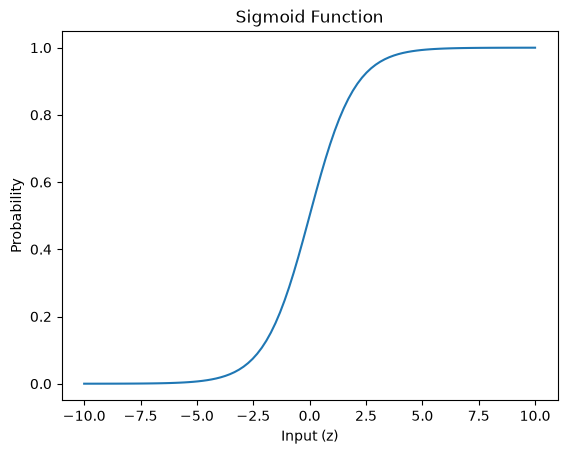

In [36]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 100)
probability = sigmoid(z)

plt.plot(z, probability)
plt.title('Sigmoid Function')
plt.xlabel('Input (z)')
plt.ylabel('Probability')
plt.show()

### 2.3 Fit a Simple Logistic Regression
We will fit a logistic regression model using 'radius_mean' to predict 'diagnosis'

In [ ]:
#import statsmodels
import statsmodels.api as sm

#Create predictor variable X (as DataFrame) and target variable y
X = df[['radius_mean']]
y = df['diagnosis']

#Add a constant to the predictor variable for the intercept term (y=mx+c) -- constant 'c' is the intercept term
X = sm.add_constant(X)
#Model y using X with logistic regression
model = sm.Logit(y, X)
result = model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.289992
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:              diagnosis   No. Observations:                  569
Model:                          Logit   Df Residuals:                      567
Method:                           MLE   Df Model:                            1
Date:                Wed, 26 Aug 2026   Pseudo R-squ.:                  0.5608
Time:                        15:56:12   Log-Likelihood:                -165.01
converged:                       True   LL-Null:                       -375.72
Covariance Type:            nonrobust   LLR p-value:                 1.192e-93
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const         -15.2459      1.325    -11.509      0.000     -17.842     -12.649
radius_mean     1.0336    

### 2.4 Odds Ratio

The logistic regression coefficient represents the change in log-odds associated with a one-unit increase in the predictor.

Exponentiating the coefficients converts it into an odds ratio.

In [ ]:
#extract coefficients (result.params) and calculate odds ratios by exponentiating the coefficients
odds_ratio = np.exp(result.params)
print(f"Odds Ratios: \n{odds_ratio}")

Odds Ratios: 
const          2.392227e-07
radius_mean    2.811136e+00
dtype: float64


### 2.5 Interpreting the Odds Ratio

The odds ratio for 'radius_mean' is 2.81. 
This means that for every 1 unit increase in mean nuclear radius, the estimated odds of the sample being malignant are multiplied by approximately 2.81. 

### 2.6 Statistical Significance using Wald's test

The p-value for 'radius_mean' is less than 0.05, indicating that the association between 'radius_mean' and the odds of malignancy is statistically significant. Therefore, there is evidence that 'radius_mean' is associated with the diagnosis in this dataset.

In [ ]:
print(f"p-value for radius_mean: {result.pvalues['radius_mean']}")

p-value for radius_mean: 1.2510153348447176e-28


### 2.7 Confidence Interval for the Odds Ratio

The 95% confidence interval for the logistic regression coefficient is expressed on the log-odds scale. Exponentiating the confidence interval converts it to the odds-ratio scale.

In [ ]:
#95% CI for coefficients
confidence_intervals = result.conf_int()
#rename the columns of the confidence intervals DataFrame for clarity
confidence_intervals.columns = ['2.5%', '97.5%']
#Exponentiate the confidence intervals of log-odds to get the confidence intervals for the odds ratios
odds_ratios_ci = np.exp(confidence_intervals)
print(f"Confidence Intervals for Odds Ratios: \n{odds_ratios_ci}")
print(f"\nConfidence Intervals for radius mean: \n{odds_ratios_ci.loc['radius_mean']}")

Confidence Intervals for Odds Ratios: 
                     2.5%     97.5%
const        1.783146e-08  0.000003
radius_mean  2.342195e+00  3.373966

Confidence Intervals for radius mean: 
2.5%     2.342195
97.5%    3.373966
Name: radius_mean, dtype: float64


### 2.8 Predicting Probability

The fitted logistic regression model can be used to estimate the probability that a sample is malignant based on its 'radius_mean'.

In [54]:
predicted_probabilities = result.predict(X)
print(f"Predicted Probabilities: \n{predicted_probabilities.head()}")

df['predicted_probability'] = predicted_probabilities
df[['radius_mean', 'diagnosis', 'predicted_probability']].head(10)

Predicted Probabilities: 
0    0.966052
1    0.997564
2    0.993973
3    0.031000
4    0.996749
dtype: float64


,radius_mean,diagnosis,predicted_probability
0,17.99,1,0.966052
1,20.57,1,0.997564
2,19.69,1,0.993973
3,11.42,1,0.031000
4,20.29,1,0.996749
5,12.45,1,0.084890
6,18.25,1,0.973843
7,13.71,1,0.254384
8,13.00,1,0.140733
9,12.46,1,0.085696


### 2.9 Classification & Classification Metrics

The model produces a probability between 0 and 1. To make a binary prediction, a threshold of 0.5 will be used:
- Predicted probability >= 0.5 --> malignant (1)
- Predicted probability <0.5 --> benign (0)

After which, we can compare the predicted classes with the actual classes using a confusion matrix and several classification metrics.

In [59]:
#Predict class based on probability threshold of 0.5
predicted_class = (predicted_probabilities >= 0.5).astype(int)
df['predicted_class'] = predicted_class
df[['radius_mean', 'diagnosis', 'predicted_probability', 'predicted_class']].head(10)

#Confusion matrix
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score
cm = confusion_matrix(y, predicted_class)
print(f"Confusion Matrix: \n{cm}")
print(f"Accuracy: {accuracy_score(y, predicted_class):.3f}")
print(f"Recall (Sensitivity): {recall_score(y, predicted_class):.3f}")
print(f"Precision: {precision_score(y, predicted_class):.3f}")

Confusion Matrix: 
[[333  24]
 [ 45 167]]
Accuracy: 0.879
Recall (Sensitivity): 0.788
Precision: 0.874


#### Logistic Regression Model Metrics

The model correctly classified 333 benign (true negatives) and 167 malignant (true positives) samples. It incorrectly classified 24 benign samples as malignant (false positives), and 45 malignant samples as benign (false negatives). 

The model achieved:
- Accuracy: 87.9% -- correctly classified 87.9% of samples overall
- Sensitivity/Recall: 78.8% -- correctly identified 78.8% of malignant samples
- Precision: 87.4% -- among samples predicted as malignant, 87.4% were actually malignant

The initial logistic regression model using radius_mean alone achieved 87.9% accuracy and showed a statistically significant association between cell nuclear radius and malignancy. However, the relatively lower sensitivity of 78.8% indicates that using radius_mean alone is insufficient for reliably identifying all malignant samples. 

### 2.10 Maximum Likelihood, Likelihood Ratio Test, & Pseudo R^2

Logistic Regression estimates its coefficients using Maximum Likelihood. The method finds the coefficients that maximises the likelihood of observing the actual outcomes in the dataset, given the model's predicted probabilities.

The likelihood-ratio test compares the fitted model with a null model containing only the intercept, testing whether including 'radius_mean' significantly improves the model's ability to explain the diagnosis.

Unlike linear regression, logistic regression does not use standard R^2. Instead, several pseudo R^2 measures can be used to assess model fit. Here, we use the McFadden's Pseudo R^2. 

In [ ]:
#Model Evaluation for Maximum Likelihood (model Fitted earlier in 2.3)
print(f"Log-Likelihood: {result.llf:.3f}")
print(f"Number of iterations: {result.mle_retvals['iterations']}")

#Likelihood Ratio Test
print(f"Likelihood-Ratio Statistic: {result.llr:.3f}")
print(f"LR Test p-value: {result.llr_pvalue:.3e}")

#Pseudo R^2
print(f"McFadden's Psuedo R^2: {result.prsquared:.3f}")

Log-Likelihood: -165.005
Number of iterations: 8
Likelihood-Ratio Statistic: 421.429
LR Test p-value: 1.192e-93
McFadden's Psuedo R^2: 0.561


## 3. Multiple Logistic Regression

The initial logistic regression model using radius_mean alone has a relatively lower sensitivity of 78.8% indicates that using radius_mean alone is insufficient for reliably identifying all malignant samples. 

### 3.1 Fit a Multiple Logistic Regression Model

In this section, we will fit a multiple logistic regression model using radius_mean, texture_mean, smoothness_mean, symmetry_mean, and concavity_mean to see if having these predictors improves the metrics of the newer regression model. 

In [69]:
#Select 5 features
features = ['radius_mean', 'texture_mean', 'smoothness_mean', 'symmetry_mean', 'concavity_mean']

#Model X using y
X = df[features]
y = df['diagnosis']
X = sm.add_constant(X)
model_multiple = sm.Logit(y, X)
result_multiple = model_multiple.fit()
print(result_multiple.summary())

Optimization terminated successfully.
         Current function value: 0.140654
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:              diagnosis   No. Observations:                  569
Model:                          Logit   Df Residuals:                      563
Method:                           MLE   Df Model:                            5
Date:                Thu, 27 Aug 2026   Pseudo R-squ.:                  0.7870
Time:                        11:01:49   Log-Likelihood:                -80.032
converged:                       True   LL-Null:                       -375.72
Covariance Type:            nonrobust   LLR p-value:                1.476e-125
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -40.7380      5.071     -8.034      0.000     -50.676     -30.800
radius_mean  

### 3.2 Odds Ratios

The coefficients from a multiple logistic regression model can be exponentiated to obtain odds ratios.

In a multiple logistic regression model, each odds ratio represents the change in the odds of malignancy associated with a one-unit increase in that predictor, while holding the other predictors constant.

The model produced very large odds ratios for some predictors, particularly 'smoothness_mean', 'symmetry_mean', and 'concavity_mean'. These should be interpreted cautiously because the model reported possible quasi-separation. Despite the large odds ratio for 'symmetry_mean', its p-value is 0.180, indicating that there is insufficient evidence that its coefficient differs from 0 in this model.

In [ ]:
#Exponentiate coefficients to obtain odds ratios
odds_ratios_multiple = np.exp(result_multiple.params)
print(odds_ratios_multiple)

const              2.031047e-18
radius_mean        3.671695e+00
texture_mean       1.466386e+00
smoothness_mean    4.408929e+44
symmetry_mean      1.748834e+06
concavity_mean     1.102739e+08
dtype: float64


### 3.3 Statistical Significance

We now check whether each predictor remains statistically significant after accounting for the other predictors in the model.

After accounting for other predictors, 'radius_mean', 'texture_mean', 'smoothness_mean', and 'concavity_mean' were statistically significantly associated with malignancy (p<0.001).

'Symmetry_mean' was not statistically significant (p=0.180).

In [78]:
results_multiple = pd.DataFrame({'Coefficient': result_multiple.params, 'Odds Ratio': np.exp(result_multiple.params), 'P-value': result_multiple.pvalues})
print(results_multiple)

                 Coefficient    Odds Ratio       P-value
const             -40.737980  2.031047e-18  9.417006e-16
radius_mean         1.300653  3.671695e+00  1.887805e-15
texture_mean        0.382801  1.466386e+00  9.719075e-10
smoothness_mean   102.797376  4.408929e+44  4.466536e-06
symmetry_mean      14.374460  1.748834e+06  1.801632e-01
concavity_mean     18.518478  1.102739e+08  1.034713e-05


### 3.4 Confidence Intervals

As with the single-predictor model, we will calculate the 95% confidence intervals for the odds ratios. This lets us see the range of plausible values for the odds ratio.

In [84]:
#Get 95% CI and rename columns
confidence_intervals_multiple = result_multiple.conf_int()
confidence_intervals_multiple.columns = ['2.5%', '97.5%']
#Exponentiate log odds ratio to get odds ratio
odds_ratios_ci_multiple = np.exp(confidence_intervals_multiple)
print(f"95% Confidence Intervals for Odds Ratios: \n{odds_ratios_ci_multiple}")

#Cleaner summary
results_multiple = pd.DataFrame({'Coefficient': result_multiple.params, 'Odds Ratio': np.exp(result_multiple.params), '2.5%': odds_ratios_ci_multiple['2.5%'], '97.5%': odds_ratios_ci_multiple['97.5%'], 'P-value': result_multiple.pvalues})
print(results_multiple)

95% Confidence Intervals for Odds Ratios: 
                         2.5%         97.5%
const            9.809733e-23  4.205162e-14
radius_mean      2.664282e+00  5.060029e+00
texture_mean     1.297041e+00  1.657841e+00
smoothness_mean  3.751714e+25  5.181273e+63
symmetry_mean    1.298534e-03  2.355286e+15
concavity_mean   2.937211e+04  4.140096e+11
                 Coefficient    Odds Ratio          2.5%         97.5%  \
const             -40.737980  2.031047e-18  9.809733e-23  4.205162e-14   
radius_mean         1.300653  3.671695e+00  2.664282e+00  5.060029e+00   
texture_mean        0.382801  1.466386e+00  1.297041e+00  1.657841e+00   
smoothness_mean   102.797376  4.408929e+44  3.751714e+25  5.181273e+63   
symmetry_mean      14.374460  1.748834e+06  1.298534e-03  2.355286e+15   
concavity_mean     18.518478  1.102739e+08  2.937211e+04  4.140096e+11   

                      P-value  
const            9.417006e-16  
radius_mean      1.887805e-15  
texture_mean     9.719075e-10  
sm

### 3.5 Comparing Simple and Multiple Logistic Regression

We will compare the one-predictor model (only radius_mean) with the multiple-predictor model to see whether adding predictors improves model fit.

The multiple logistic regression model has a substantially higher log-likelihood and pseudo R^2 than the simple model. The likelihood-ratio test also indicates that the multiple model provides a statistically significant improvement in model fit. Adding the additional predictors therefore improves the model compared with using 'radius_mean' alone.

In [90]:
comparison = pd.DataFrame({'Simple Model': [result.llf, result.prsquared, result.llr_pvalue], 'Multiple Model': [result_multiple.llf, result_multiple.prsquared, result_multiple.llr_pvalue]}, index=['Log-Likelihood', 'McFadden Pseudo R^2', 'LR Test p-value'])
print(comparison)

                     Simple Model  Multiple Model
Log-Likelihood      -1.650054e+02   -8.003198e+01
McFadden Pseudo R^2  5.608288e-01    7.869904e-01
LR Test p-value      1.192267e-93   1.476172e-125


### 3.6 Final Model Summary

The multiple logistic regression model performed substantially better than the simple logistic regression model using 'radius_mean' alone.

The five predictors were: 'radius_mean', 'texture_mean', 'smoothness_mean', 'symmetry_mean', and 'concavity_mean'. 

'Symmetry_mean' was not statistically significant after accounting for other predictors (p=0.180). The other four predictors were statistically significant at p<0.05. 

The model achieved a McFadden Pseudo R^2 of 0.787 and a statistically significant likelihood-ratio test (p<0.001).

However, the model showed possible quasi-separation, so the very large odds ratios for some predictors should be interpreted with caution.

## 04. Key Takeaways

Through this notebook, I applied logistic regression to a real-world healthcare (breast cancer) dataset and explored:

- Binary classification
- Logistic Function
- Log-Odds
- Maximum Likelihood
- Logistic Regression Coefficient
- Odds Ratios
- Wald's Test and p-values
- Confidence Intervals
- Predicted Probabilities
- Classification metrics
- Multiple Logistic Regression
- Likelihood-ratio testing
- Pseudo R^2

Logistic regression models the relationship between predictor variables and the probability of a binary outcome (yes or no, 1 or 0). Coefficients can be converted into odds ratios to quantify the relationship.